# 6 #
(a) Consider (6.12) with p =1. For some choice of y1 and λ > 0,
plot (6.12) as a function of β1. Your plot should confirm that
(6.12) is solved by (6.14).

(6.12)  $\sum{(y_j - \beta_j)^2} + \lambda \sum{\beta_j^2}$

(6.14) $\hat{\beta}_j^R = y_j/(1 + \lambda)$

In [651]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

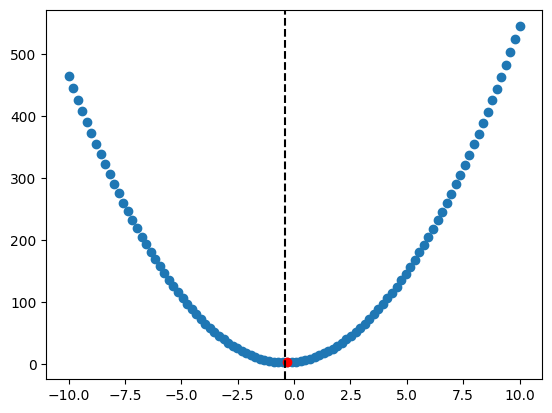

In [652]:
def func_6_12(y, beta, lmbda):
    return (y - beta)**2 + lmbda * beta**2

def func_6_14(y, lmbda):
    beta_ridge = y/(1+lmbda)
    return beta_ridge

lmbda = np.random.randint(low=1, high=10)
y_real = np.random.randint(low=-10, high=10)
valores_beta = np.linspace(-10, 10, 100)

y_predicoes = func_6_12(y_real,valores_beta,lmbda)
beta_min = func_6_14(y_real, lmbda)
plt.scatter(valores_beta, y_predicoes)
plt.scatter(valores_beta[np.argmin(y_predicoes)], np.min(y_predicoes), color='r');
plt.axvline(beta_min, ls='--', c='k')

6(b) Consider (6.13) with p =1. For some choice of y1 and λ > 0,
plot (6.13) as a function of β1. Your plot should confirm that
(6.13) is solved by (6.15).

(6.13) $\sum{(y_j - \beta_j)^2 + \lambda \sum{|\beta_j|}}$

(6.15) $\hat{\beta}_j^L = 
\begin{cases} 
y_j - \lambda/2 & \text{if } y_j > \lambda/2; \\
y_j + \lambda/2 & \text{if } y_j < -\lambda/2;\\
0 & \text{if } |y_j| \leq \lambda/2.
\end{cases}$

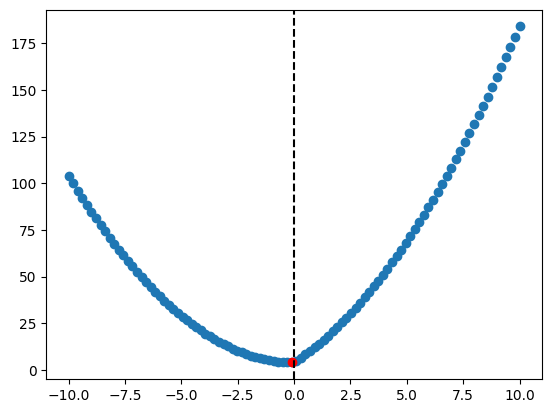

In [653]:
def func_6_13(y, beta, lmbda):
    return (y-beta)**2 + lmbda * np.abs(beta)

def func_6_15(y, lmbda):
    if y > lmbda/2:
        return y - lmbda/2
    elif y < (-lmbda/2):
        return y + lmbda/2
    else:
        return 0

y_predicoes_lasso = func_6_13(y_real, valores_beta, lmbda)
beta_min_lasso = func_6_15(y_real,lmbda)

plt.scatter(valores_beta, y_predicoes_lasso)
plt.scatter(valores_beta[np.argmin(y_predicoes_lasso)], np.min(y_predicoes_lasso), color='r');
plt.axvline(beta_min_lasso, ls='--', c='k')

# 8 #
In this exercise, we will generate simulated data, and will then use
this data to perform forward and backward stepwise selection.

(a) Create a random number generator and use its normal() method
to generate a predictor X of length n = 100, as well as a noise
vector ϵ of length n = 100.

(b) Generate a response vector Y of length n = 100 according to
the model
$Y =\beta_0+\beta_1X+\beta_2X^2+\beta_3X^3+ϵ$,
where β0, β1, β2, and β3 are constants of your choice.

In [654]:
rng = np.random.default_rng(42)
x = rng.normal(size=100)
ruido = rng.normal(size=100)
y = 8 + 4*x + 36*x**2 + 50*x**3 + ruido

$Y =8 +4X+36X^2+50X^3+ϵ$

(c) Use forward stepwise selection in order to select a model contain
ing the predictors $X,X^2,...,X^{10}$. What is the model obtained
according to Cp? Report the coefficients of the model obtained.

fórmula 6.2 página 236 do livro ISLP

$C_p= 1/n (RSS + 2d\hat{\sigma}^2)$

ou

$C_p'=RSS/\hat{\sigma}^2 + 2d - n $

$d =$ número de preditores

$\hat{\sigma}^2 =$ Variância do modelo com todos os preditores



In [655]:
def nCp(variancia, modelo, X, Y):
    n, p = X.shape
    Y_predicoes = modelo.predict(X)
    RSS = np.sum((Y -Y_predicoes)**2)
    return - (RSS + 2 * p * variancia)/n

X = pd.DataFrame()
for i in range(1,11):
    X[f'x_{i}'] = x**i

In [656]:
from statsmodels.api import OLS
from ISLP.models import summarize, ModelSpec


design = ModelSpec(X).fit(X)
modelo_completo = OLS(y, design.transform(X)).fit()
print("R2 modelo completo:", modelo_completo.rsquared)
variancia_modelo_completo = modelo_completo.scale

print("Variância modelo completo:", variancia_modelo_completo)
summarize(modelo_completo)

R2 modelo completo: 0.9998810303564758
Variância modelo completo: 0.9597290861769199


,coef,std err,t,P>|t|
intercept,7.9847,0.235,34.025,0.000
x_1,3.2076,0.728,4.408,0.000
x_2,36.0302,2.335,15.429,0.000
x_3,54.0783,2.970,18.207,0.000
x_4,1.9992,5.774,0.346,0.730
x_5,-5.6819,3.580,-1.587,0.116
x_6,-3.4560,5.223,-0.662,0.510
x_7,2.6060,1.497,1.741,0.085
x_8,1.6232,1.874,0.866,0.389
x_9,-0.3360,0.184,-1.824,0.072


In [657]:
from functools import partial
from ISLP.models import Stepwise, sklearn_selected

neg_Cp = partial(nCp,variancia_modelo_completo)
estrategia_forward = Stepwise.first_peak(model_spec=design,
                                 direction='forward',
                                 max_terms=len(design.terms))
modelo_forward_Cp = sklearn_selected(model_type=OLS,
                          strategy=estrategia_forward,
                          scoring=neg_Cp)

modelo_forward_Cp.fit(X, y)
print("R2 modelo foward selection Cp:", modelo_forward_Cp.results_.rsquared)
print("MSE modelo foward selection Cp:", modelo_forward_Cp.results_.mse_resid)
summarize(modelo_forward_Cp.results_)

R2 modelo foward selection Cp: 0.9998731793278943
MSE modelo foward selection Cp: 0.9484650251172325


,coef,std err,t,P>|t|
intercept,8.1167,0.123,66.238,0.0
x_1,3.9235,0.207,18.965,0.0
x_2,35.8054,0.125,287.058,0.0
x_3,50.0940,0.097,514.756,0.0


O modelo com foward selection selecionou apenas as colunas que fazem parte da equação que gerou Y.

Equação de origem: $Y =8 +4X+36X^2+50X^3+ϵ$

Equação modelo foward selection Cp: $\hat{Y} =8.1167 +3.9235X+35.8054X^2+50.0940X^3$

(d) Repeat (c), using backwards stepwise selection. How does your
answer compare to the results in (c)?

In [658]:
estrategia_backward = Stepwise.first_peak(model_spec=design,
                                          direction='backwards',
                                          max_terms=len(design.terms))
modelo_backward_Cp = sklearn_selected(model_type=OLS,
                                      strategy=estrategia_backward,
                                      scoring=neg_Cp)

modelo_backward_Cp.fit(X, y)

print("R2 modelo backward selection Cp:", modelo_backward_Cp.results_.rsquared)
print("MSE modelo backward selection Cp:", modelo_backward_Cp.results_.mse_resid)
summarize(modelo_backward_Cp.results_)

R2 modelo backward selection Cp: 0.9998731793278943
MSE modelo backward selection Cp: 0.9484650251172325


,coef,std err,t,P>|t|
intercept,8.1167,0.123,66.238,0.0
x_1,3.9235,0.207,18.965,0.0
x_2,35.8054,0.125,287.058,0.0
x_3,50.0940,0.097,514.756,0.0


Os modelos com foward e backward selection chegaram no mesmo resultado

(e) Now fit a lasso model to the simulated data, again using X,X2,
...,X10 as predictors. Use cross-validation to select the optimal
value of λ. Create plots of the cross-validation error as a function
of λ. Report the resulting coefficient estimates, and discuss the
results obtained.

In [659]:
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

l_cv = LassoCV(n_alphas=100, cv=5)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', l_cv)
])
pipe.fit(X, y)
l_cv = pipe.named_steps['lasso']
print(f'Alfa: {l_cv.alpha_}\nR2: {pipe.score(X, y)}\nMSE: {mean_squared_error(y, pipe.predict(X))}')
coeficientes = np.append(l_cv.intercept_, l_cv.coef_)
pd.DataFrame(np.append(l_cv.intercept_, l_cv.coef_), index=np.append('intercepto',X.columns), columns=['coeficiente'])

Alfa: 0.08571924399223015
R2: 0.9998705859828942
MSE: 0.9291457005301177


c:\Users\olive\.conda\envs\ISLP\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


,coeficiente
intercepto,21.708029
x_1,2.967586
x_2,28.450070
x_3,81.308542
x_4,0.000000
x_5,0.000000
x_6,0.000000
x_7,0.000000
x_8,0.000000
x_9,0.000000


<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
C:\Users\olive\AppData\Local\Temp\ipykernel_2428\3544408485.py:8: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$-\log(\lambda)$', fontsize=20)


Text(0, 0.5, 'Cros-validated MSE')

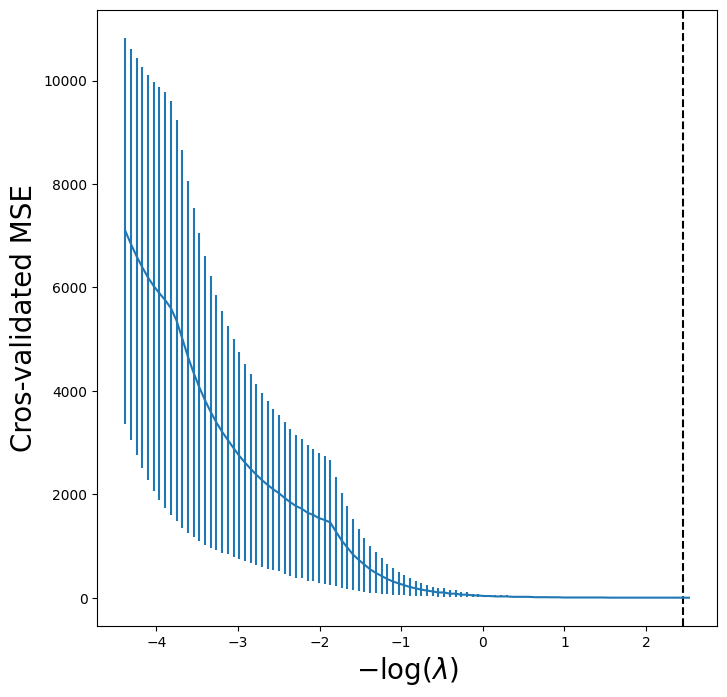

In [660]:
from matplotlib.pyplot import subplots

l_cv_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(l_cv.alphas_),
            l_cv.mse_path_.mean(1),
            yerr=l_cv.mse_path_.std(1)/ np.sqrt(5))
ax.axvline(-np.log(l_cv.alpha_), c='k', ls='--');
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Cros-validated MSE', fontsize=20)

(f) Now generate a response vector Y according to the model

$Y =\beta_0+\beta_7X^7+\epsilon$

In [661]:
y_2 = 28 + 6*x**7 + ruido*10

In [662]:
modelo_completo_2 = OLS(y_2, X).fit()
variancia_modelo_completo_2 = modelo_completo_2.scale

print("R2 modelo completo:", modelo_completo_2.rsquared)
print("Variância modelo completo:", variancia_modelo_completo_2)

summarize(modelo_completo_2)

R2 modelo completo: 0.9899442169964725
Variância modelo completo: 245.06145167339102


,coef,std err,t,P>|t|
x_1,-1.7944,11.599,-0.155,0.877
x_2,217.0056,23.256,9.331,0.000
x_3,-7.5945,47.012,-0.162,0.872
x_4,-423.1427,70.366,-6.013,0.000
x_5,11.0049,56.467,0.195,0.846
x_6,314.7750,68.940,4.566,0.000
x_7,3.5604,23.607,0.151,0.880
x_8,-97.1469,25.754,-3.772,0.000
x_9,-0.2845,2.915,-0.098,0.922
x_10,10.3001,3.071,3.354,0.001


In [663]:
neg_Cp_2 = partial(nCp, variancia_modelo_completo_2)

modelo_forward_Cp_2 = sklearn_selected(model_type=OLS,
                                       strategy=estrategia_forward,
                                       scoring=neg_Cp_2)
modelo_forward_Cp_2.fit(X, y_2)
print("R2 modelo foward selection Cp:", modelo_forward_Cp_2.results_.rsquared)
print("MSE modelo foward selection Cp:", modelo_forward_Cp_2.results_.mse_resid)
summarize(modelo_forward_Cp_2.results_)


R2 modelo foward selection Cp: 0.9955316911822343
MSE modelo foward selection Cp: 96.55992409048244


,coef,std err,t,P>|t|
intercept,27.8954,0.983,28.388,0.0
x_7,6.0248,0.041,147.764,0.0


In [664]:

l_cv_2 = LassoCV(n_alphas=100, cv=5)

pipe_2 = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', l_cv_2)
])
pipe_2.fit(X, y_2)
l_cv_2 = pipe_2.named_steps['lasso']
print(f'Alfa: {l_cv_2.alpha_}\nR2: {pipe_2.score(X, y_2)}\nMSE: {mean_squared_error(y_2, pipe_2.predict(X))}')
pd.DataFrame(np.append(l_cv_2.intercept_,l_cv_2.coef_), index=np.append('intercepto', X.columns), columns=['coeficiente'])

Alfa: 0.1556934995277739
R2: 0.995713673563776
MSE: 90.77474828730749


c:\Users\olive\.conda\envs\ISLP\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


,coeficiente
intercepto,27.485107
x_1,-1.353401
x_2,-0.000000
x_3,-0.000000
x_4,-0.955966
x_5,24.503923
x_6,-0.000000
x_7,101.692164
x_8,-0.000000
x_9,20.360668


o Foward Selection Selecionou apenas o preditor correto e finalizou o modelo bem próximo ao modelo verdadeiro.

$Y = 28 + 6 x^7 + \epsilon$

$\hat{Y} = 27.8954 + 6.0248 x^7$

O lasso porém, considerou mais preditores

$\hat{Y}´ = 27.485107 + -1.353401x^1 -0.955966x^4 + 24.503923 x^5 + 101.692164 x^7 + 20.360668 x^9$

Isso indica que o modelo com o lasso apesar de fazer uma seleção de preditores, ainda há valores de coeficientes que não respresentam o modelo verdadeiro, o modelo está tentando explicar o ruído do sistema.

# 9 #
In this exercise, we will predict the number of applications received
using the other variables in the College data set.

(a) Split the data set into a training set and a test set.

In [665]:
from ISLP import load_data
from sklearn.model_selection import train_test_split

College = load_data('College')
X_treino, X_teste, y_treino, y_teste = train_test_split(College.drop(columns=['Apps']), College.Apps, random_state=42)
College.head(3)


,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54


(b) Fit a linear model using least squares on the training set, and
report the test error obtained.

In [666]:

modelo_linear = OLS(y_treino, ModelSpec(X_treino).fit_transform(X_treino)).fit()
modelo_linear.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Apps   R-squared:                       0.943
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     553.7
Date:                Thu, 20 Aug 2026   Prob (F-statistic):               0.00
Time:                        17:33:51   Log-Likelihood:                -4809.1
No. Observations:                 582   AIC:                             9654.
Df Residuals:                     564   BIC:                             9733.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept     -259.5390    436.386     -0.595      0.552   -1116.679     597.601
Private[Yes]  -626.4455    152.328     -4.112      0.000    -925.646    -327.245
Accept           1.7156      0.043     39.588      0.000       1.630       1.801
Enroll          -1.2578      0.198     -6.368      0.000      -1.646      -0.870
Top10perc       43.8312      5.805      7.551      0.000      32.429      55.233
Top25perc      -10.0355      4.716     -2.128      0.034     -19.298      -0.773
F.Undergrad      0.0626      0.035      1.775      0.076      -0.007       0.132
P.Undergrad     -0.0126      0.042     -0.299      0.765      -0.096       0.070
Outstate        -0.0763      0.020     -3.814      0.000      -0.116      -0.037
Room.Board       0.1739      0.052      3.369      0.001       0.072       0.275
Books            0.1170      0.261      0.448      0.654      -0.396       0.629
Personal         0.0614      0.067      0.910      0.363      -0.071       0.194
PhD            -10.5702      5.103     -2.071      0.039     -20.593      -0.547
Terminal        -1.1547      5.484     -0.211      0.833     -11.926       9.617
S.F.Ratio       13.0572     13.433      0.972      0.331     -13.327      39.441
perc.alumni      0.6542      4.412      0.148      0.882      -8.012       9.320
Expend           0.0442      0.012      3.544      0.000       0.020       0.069
Grad.Rate        7.0856      3.021      2.345      0.019       1.151      13.020
==============================================================================
Omnibus:                      366.204   Durbin-Watson:                   1.777
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             9238.224
Skew:                           2.316   Prob(JB):                         0.00
Kurtosis:                      21.961   Cond. No.                     1.85e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.85e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""